In [28]:
import pandas as pd
import matplotlib.pyplot as plt 
import sklearn as sk 


In [29]:
df = pd.read_csv(r"D:\Repos\ML-Practice\ML\Uber\Dataset\cleaned_uber.csv")

In [30]:
df.head(40)

,fare_amount,passenger_count,month,day,weekday,year,hour,distance
0,7.5,1,5,7,3,2015,19,1.683323
1,7.7,1,7,17,4,2009,20,2.457590
2,12.9,1,8,24,0,2009,21,5.036377
3,5.3,3,6,26,4,2009,8,1.661683
4,16.0,5,8,28,3,2014,17,4.475450
5,4.9,1,2,12,5,2011,2,0.000000
6,24.5,5,10,12,6,2014,7,11.731015
7,2.5,1,12,11,1,2012,13,0.000000
8,9.7,1,2,17,4,2012,9,2.332711
9,12.5,1,3,29,3,2012,19,4.889417


In [31]:
Q1 = df['fare_amount'].quantile(0.25)
Q3 = df['fare_amount'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1 * IQR

print(upper_bound)

df = df[(df['fare_amount'] >= 0) & (df['fare_amount'] <= upper_bound)]

Q1 = df['distance'].quantile(0.25)
Q3 = df['distance'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1 * IQR

print(upper_bound)

df = df[(df['distance'] >= 0) & (df['distance'] <= upper_bound)]



19.0
5.131216059635799


In [32]:
X = df[["passenger_count",	"month", 	"day",	"weekday",	"hour",	"distance"]]
y = df["fare_amount"]

In [33]:
df.info()

<class 'pandas.DataFrame'>
Index: 163717 entries, 0 to 199997
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   fare_amount      163717 non-null  float64
 1   passenger_count  163717 non-null  int64  
 2   month            163717 non-null  int64  
 3   day              163717 non-null  int64  
 4   weekday          163717 non-null  int64  
 5   year             163717 non-null  int64  
 6   hour             163717 non-null  int64  
 7   distance         163717 non-null  float64
dtypes: float64(2), int64(6)
memory usage: 11.2 MB


In [34]:
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(
    X, y, test_size=0.33, random_state=42)

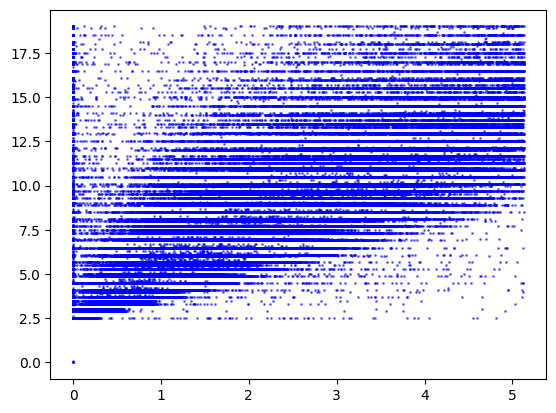

In [35]:
plt.scatter(df['distance'], df['fare_amount'], color='blue', alpha=0.5, s=1)

In [36]:
scaler = sk.preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [37]:
model = sk.linear_model.LinearRegression()
model = model.fit(X_train,y_train)
y_train_pred = model.predict(X_train)

In [38]:
sk.metrics.mean_absolute_error(y_train, y_train_pred)

1.6335356861608659

In [39]:

y_test_pred = model.predict(X_test)
sk.metrics.mean_absolute_error(y_test, y_test_pred)

1.6365753061167354